Design Mach Number: 1.502
Geometry successfully saved to nozzle_contour.csv


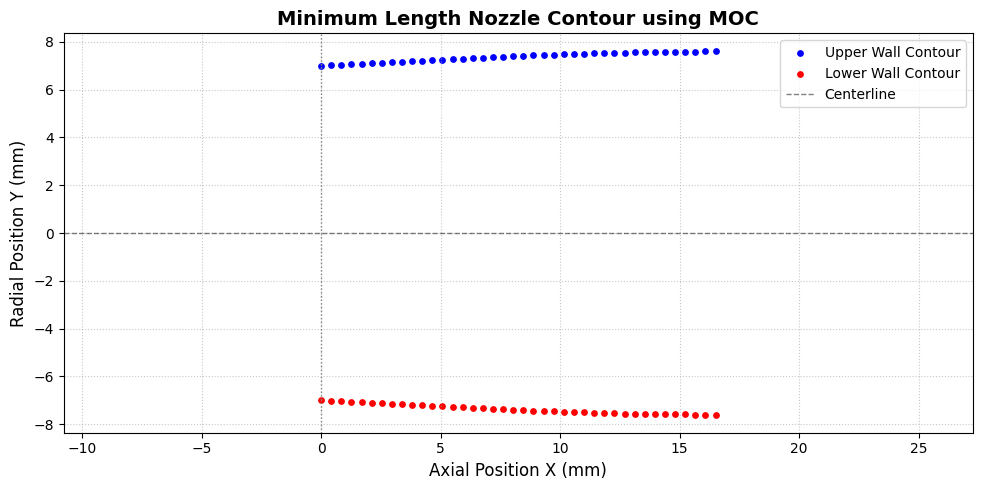

In [5]:
"""
Minimum Length Converging-Diverging Nozzle Contour Generator
Method: Method of Characteristics (MOC) with Uniform Resampling
Author: [Praveen Kumar Baluguri]

Description:
Generates the wall coordinates for a perfectly expanded, minimum-length
supersonic nozzle using the Method of Characteristics. The solver maps a
2D planar characteristic network to an axisymmetric area ratio, rigorously
pins the boundary conditions, and resamples the geometry using a shape-preserving
spline to ensure equally spaced points for clean CAD/manufacturing import.
"""

import numpy as np
import matplotlib.pyplot as plt
import csv
from scipy.optimize import fsolve, brentq
from scipy.interpolate import PchipInterpolator

# ==========================================
# 1. DESIGN PARAMETERS & INPUTS
# ==========================================
GAMMA = 1.4             # Specific heat ratio for air
D_T = 14.0              # Throat diameter (mm)
D_E = 15.19             # Exit diameter (mm)
N_LINES = 25            # Number of characteristic lines (resolution)
NUM_OUTPUT_POINTS = 40  # Number of equally spaced points for final CSV

R_T = D_T / 2.0
R_E = D_E / 2.0
A_RATIO = (R_E / R_T)**2

class Node:
    """Data structure to hold flow properties at each characteristic intersection."""
    def __init__(self, x, y, theta, nu, mach, mu):
        self.x = x
        self.y = y
        self.theta = theta
        self.nu = nu
        self.mach = mach
        self.mu = mu

# ==========================================
# 2. GAS DYNAMICS FUNCTIONS
# ==========================================
def prandtl_meyer(M):
    """Calculates the Prandtl-Meyer angle (nu) for a given Mach number."""
    term1 = np.sqrt((GAMMA + 1) / (GAMMA - 1))
    term2 = np.arctan(np.sqrt((GAMMA - 1) / (GAMMA + 1) * (M**2 - 1)))
    term3 = np.arctan(np.sqrt(M**2 - 1))
    return term1 * term2 - term3

def get_mach_from_nu(nu_target):
    """Inverse Prandtl-Meyer function using root finding."""
    if nu_target < 1e-5:
        return 1.0001
    func = lambda M: prandtl_meyer(M) - nu_target
    return brentq(func, 1.0001, 10.0)

def area_ratio_eq(M):
    """Axisymmetric area ratio equation to find exit Mach number."""
    t1 = 1.0 / M
    t2 = (2.0 + (GAMMA - 1) * M**2) / (GAMMA + 1)
    t3 = (GAMMA + 1) / (2 * (GAMMA - 1))
    return t1 * (t2**t3) - A_RATIO

# ==========================================
# 3. INITIALIZATION & MESH GENERATION
# ==========================================
M_e = fsolve(area_ratio_eq, 2.0)[0]
nu_e = prandtl_meyer(M_e)
theta_max = nu_e / 2.0

d_theta = theta_max / N_LINES
theta_init = np.array([(i + 1) * d_theta for i in range(N_LINES)])
nodes = np.empty((N_LINES, N_LINES), dtype=object)

for i in range(N_LINES):
    for j in range(i + 1):
        theta_ij = theta_init[i] - theta_init[j]
        nu_ij = theta_init[i] + theta_init[j]
        M_ij = get_mach_from_nu(nu_ij)
        mu_ij = np.arcsin(1.0 / M_ij)

        if i == j:
            y_ij = 0.0
            if i == 0:
                mu_corner = np.arcsin(1.0 / get_mach_from_nu(theta_init[0]))
                m_minus = np.tan(0.5*(theta_init[0] + 0) - 0.5*(mu_corner + mu_ij))
                x_ij = 0.0 - R_T / m_minus
            else:
                prev = nodes[i, j-1]
                m_minus = np.tan(0.5*(prev.theta + theta_ij) - 0.5*(prev.mu + mu_ij))
                x_ij = prev.x - prev.y / m_minus

        elif j == 0:
            mu_corner = np.arcsin(1.0 / get_mach_from_nu(theta_init[i]))
            m_minus = np.tan(0.5*(theta_init[i] + theta_ij) - 0.5*(mu_corner + mu_ij))
            prev_plus = nodes[i-1, j]
            m_plus = np.tan(0.5*(prev_plus.theta + theta_ij) + 0.5*(prev_plus.mu + mu_ij))

            x1, y1 = 0.0, R_T
            x2, y2 = prev_plus.x, prev_plus.y
            x_ij = (y1 - y2 - m_minus*x1 + m_plus*x2) / (m_plus - m_minus)
            y_ij = y1 + m_minus*(x_ij - x1)

        else:
            prev_minus = nodes[i, j-1]
            prev_plus = nodes[i-1, j]

            m_minus = np.tan(0.5*(prev_minus.theta + theta_ij) - 0.5*(prev_minus.mu + mu_ij))
            m_plus = np.tan(0.5*(prev_plus.theta + theta_ij) + 0.5*(prev_plus.mu + mu_ij))

            x1, y1 = prev_minus.x, prev_minus.y
            x2, y2 = prev_plus.x, prev_plus.y
            x_ij = (y1 - y2 - m_minus*x1 + m_plus*x2) / (m_plus - m_minus)
            y_ij = y1 + m_minus*(x_ij - x1)

        nodes[i, j] = Node(x_ij, y_ij, theta_ij, nu_ij, M_ij, mu_ij)

# ==========================================
# 4. WALL CONTOUR TRACING
# ==========================================
wall_x_raw = [0.0]
wall_y_raw = [R_T]
wall_theta = [theta_max]

for i in range(N_LINES):
    n_plus = nodes[N_LINES-1, i]
    m_wall = np.tan(0.5 * (wall_theta[-1] + n_plus.theta))
    m_plus = np.tan(n_plus.theta + n_plus.mu)

    x1, y1 = wall_x_raw[-1], wall_y_raw[-1]
    x2, y2 = n_plus.x, n_plus.y

    x_w = (y1 - y2 - m_wall*x1 + m_plus*x2) / (m_plus - m_wall)
    y_w = y1 + m_wall*(x_w - x1)

    wall_x_raw.append(x_w)
    wall_y_raw.append(y_w)
    wall_theta.append(n_plus.theta)

# Patch the straight expansion segment
x_straight = np.linspace(wall_x_raw[0], wall_x_raw[1], 15)
y_straight = np.linspace(wall_y_raw[0], wall_y_raw[1], 15)

wall_x_full = np.array(list(x_straight) + wall_x_raw[2:])
wall_y_full = np.array(list(y_straight) + wall_y_raw[2:])

# Scale to pin D_E exactly
delta_2d = wall_y_full[-1] - R_T
delta_3d = R_E - R_T
wall_y_full = R_T + (wall_y_full - R_T) * (delta_3d / delta_2d)

# ==========================================
# 5. SHAPE-PRESERVING INTERPOLATION (UNIFORM SPACING)
# ==========================================
# Remove any duplicate X coordinates to allow interpolation
wall_x_unique, unique_indices = np.unique(wall_x_full, return_index=True)
wall_y_unique = wall_y_full[unique_indices]

# Use PchipInterpolator to avoid any non-physical wiggles/overshoots
interpolator = PchipInterpolator(wall_x_unique, wall_y_unique)

# Generate uniform X coordinates
x_uniform = np.linspace(wall_x_unique[0], wall_x_unique[-1], NUM_OUTPUT_POINTS)
y_uniform = interpolator(x_uniform)

# Rigorously enforce boundary conditions on the new resampled array
y_uniform[0] = R_T
y_uniform[-1] = R_E

# ==========================================
# 6. EXPORT & VISUALIZATION
# ==========================================
csv_filename = 'nozzle_contour.csv'
with open(csv_filename, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['X', 'Y', 'Z'])
    for x, y in zip(x_uniform, y_uniform):
        writer.writerow([round(x, 6), round(y, 6), 0.0])

print(f"Design Mach Number: {M_e:.3f}")
print(f"Geometry successfully saved to {csv_filename}")

plt.figure(figsize=(10, 5))
plt.scatter(x_uniform, y_uniform, color='blue', marker='o', s=15, label='Upper Wall Contour')
plt.scatter(x_uniform, -y_uniform, color='red', marker='o', s=15, label='Lower Wall Contour')

plt.title('Minimum Length Nozzle Contour using MOC', fontsize=14, fontweight='bold')
plt.xlabel('Axial Position X (mm)', fontsize=12)
plt.ylabel('Radial Position Y (mm)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Centerline')
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()